In [ ]:
# Cell 0: Imports + device

import os, glob, json, math, pickle, random, time
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE: cpu


In [ ]:
# Cell 1: Mount Drive

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Cell 2: Paths

DATASET_PATH = "/content/drive/MyDrive/AIAGENT_FINAL/obtain_diamond_v3_fixdone"
SEQ_DIR      = "/content/drive/MyDrive/AIAGENT_FINAL/outputs_sequences"
SWEEP_ROOT   = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep"
METRICS_DIR  = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics"
os.makedirs(METRICS_DIR, exist_ok=True)

EXPERIMENT_INDEX_PATH = os.path.join(SWEEP_ROOT, "experiment_index.json")
ROLL_RESULTS_PATH     = os.path.join(METRICS_DIR, "rollout_results.json")

train_pkl = os.path.join(SEQ_DIR, "train_sequences.pkl")
val_pkl   = os.path.join(SEQ_DIR, "val_sequences.pkl")
test_pkl  = os.path.join(SEQ_DIR, "test_sequences.pkl")
meta_json = os.path.join(SEQ_DIR, "sequences_meta.json")
norm_path = os.path.join(SEQ_DIR, "global_train_state_norm_stats.npz")

with open(test_pkl, "rb") as f:
    test_seqs = pickle.load(f)
with open(meta_json, "r") as f:
    seq_meta = json.load(f)
with open(EXPERIMENT_INDEX_PATH, "r") as f:
    experiment_index = json.load(f)

z = np.load(norm_path)
state_mean = z["state_mean"].astype(np.float32)
state_std  = z["state_std"].astype(np.float32)

SEQ_LEN = int(seq_meta["seq_len"])
BURN_IN = int(seq_meta["burn_in"])

print("Loaded test sequences:", len(test_seqs))
print("SEQ_LEN:", SEQ_LEN, "BURN_IN:", BURN_IN)
print("Num overlap runs:", len(experiment_index["runs"]))

Loaded test sequences: 149650
SEQ_LEN: 50 BURN_IN: 10
Num overlap runs: 15


In [ ]:
# Cell 3: Evaluation config

# CPU-safe defaults:
HORIZONS = [1, 2, 5, 10, 20]
STEP_OFFSET = 0              # keep this fixed for speed and consistency with Notebook 4 validation
TEST_CAP = None              # set to e.g. 10000 if CPU evaluation is too slow
BATCH_SIZE = 128 if DEVICE.type == "cuda" else 32
NUM_WORKERS = 0
SEED_EVAL = 2026

assert max(HORIZONS) <= SEQ_LEN, "Largest horizon exceeds sequence length."

print("HORIZONS:", HORIZONS)
print("STEP_OFFSET:", STEP_OFFSET)
print("TEST_CAP:", TEST_CAP)
print("BATCH_SIZE:", BATCH_SIZE)

HORIZONS: [1, 2, 5, 10, 20]
STEP_OFFSET: 0
TEST_CAP: None
BATCH_SIZE: 32


In [ ]:
# Cell 4: Shard path map

shards = sorted(glob.glob(os.path.join(DATASET_PATH, "shard_*.npz")))
path_map = {os.path.basename(p): p for p in shards}
assert len(path_map) == 30, f"Expected 30 shards, got {len(path_map)}"

def check_seq_refs(seqs, name):
    names = {s["shard"] for s in seqs}
    missing = sorted(list(names - set(path_map.keys())))
    assert len(missing) == 0, f"{name} references missing shards: {missing[:5]}"

check_seq_refs(test_seqs, "test")
print("Shard references OK.")

Shard references OK.


In [ ]:
# Cell 5: Shared normalized shard cache

_SHARD_CACHE = {}

def load_shard_cached(shard_name: str):
    if shard_name in _SHARD_CACHE:
        return _SHARD_CACHE[shard_name]

    p = path_map[shard_name]
    with np.load(p) as d:
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        action = d["action"].astype(np.float32)
        reward = d["reward"].astype(np.float32)
        done = d["done"].astype(np.bool_)

    state_raw = np.concatenate([obs, mainhand], axis=1)   # (N, 28)
    state = (state_raw - state_mean) / (state_std + 1e-8)

    _SHARD_CACHE[shard_name] = (state, action, reward, done)
    return _SHARD_CACHE[shard_name]

In [ ]:
# Cell 6: Dataset / loader

class SequenceDataset(Dataset):
    """
    Returns:
      s:   (L+1, 28) float32 states
      a:   (L,   15) float32 actions
      r:   (L,)      float32 rewards
      cont:(L,)      float32 continuation = 1 - done[t]
    """
    def __init__(self, seqs, seq_len=50):
        self.seqs = seqs
        self.L = seq_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        rec = self.seqs[idx]
        shard = rec["shard"]
        t0 = int(rec["t0"])
        L  = int(rec["length"])
        assert L == self.L

        state, action, reward, done = load_shard_cached(shard)

        s = state[t0:t0+L+1]
        a = action[t0:t0+L]
        r = reward[t0:t0+L]
        cont = 1.0 - done[t0:t0+L].astype(np.float32)

        return (
            torch.from_numpy(s),
            torch.from_numpy(a),
            torch.from_numpy(r),
            torch.from_numpy(cont),
        )

def make_loader(seqs, batch_size, shuffle=False, cap=None, seed=0):
    if cap is not None and len(seqs) > cap:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(seqs), size=cap, replace=False)
        idx = np.sort(idx)
        seqs = [seqs[i] for i in idx]

    ds = SequenceDataset(seqs, seq_len=SEQ_LEN)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    return dl, len(ds)

In [ ]:
# Cell 7: RSSM model definitions (same as Notebook 5 / 4)

def _init_layer(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

class Encoder(nn.Module):
    def __init__(self, state_dim=28, hidden=256, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, embed_dim), nn.ReLU(),
        )
        self.apply(_init_layer)

    def forward(self, s):
        return self.net(s)

class RSSM(nn.Module):
    def __init__(self, action_dim=15, deter_dim=256, stoch_dim=32, hidden=256, min_std=0.1):
        super().__init__()
        self.deter_dim = deter_dim
        self.stoch_dim = stoch_dim
        self.min_std = min_std

        self.gru = nn.GRUCell(stoch_dim + action_dim, deter_dim)

        self.prior_net = nn.Sequential(
            nn.Linear(deter_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * stoch_dim),
        )

        self.post_net = nn.Sequential(
            nn.Linear(deter_dim + hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * stoch_dim),
        )
        self.apply(_init_layer)

    def init_state(self, batch_size):
        h = torch.zeros(batch_size, self.deter_dim, device=DEVICE)
        z = torch.zeros(batch_size, self.stoch_dim, device=DEVICE)
        return h, z

    def _dist(self, params):
        mu, std = torch.chunk(params, 2, dim=-1)
        std = F.softplus(std) + self.min_std
        return mu, std

    def deter_step(self, h, z, a):
        x = torch.cat([z, a], dim=-1)
        h = self.gru(x, h)
        return h

    def prior(self, h):
        params = self.prior_net(h)
        mu, std = self._dist(params)
        return mu, std

    def posterior(self, h, embed):
        x = torch.cat([h, embed], dim=-1)
        params = self.post_net(x)
        mu, std = self._dist(params)
        return mu, std

    def sample(self, mu, std):
        eps = torch.randn_like(mu)
        return mu + eps * std

class Decoder(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256, state_dim=28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, state_dim),
        )
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        return self.net(x)

class RewardHead(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256):
        super().__init__()
        self.base = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.r_out = nn.Linear(hidden, 1)
        self.m_out = nn.Linear(hidden, 1)
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        f = self.base(x)
        r = self.r_out(f).squeeze(-1)
        m = self.m_out(f).squeeze(-1)
        return r, m

class ContHead(nn.Module):
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        return self.net(x).squeeze(-1)

class DreamerWorldModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.enc = Encoder(
            state_dim=cfg["state_dim"],
            hidden=cfg["hidden"],
            embed_dim=cfg["hidden"],
        )
        self.rssm = RSSM(
            action_dim=cfg["action_dim"],
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
            min_std=cfg["min_std"],
        )
        self.dec = Decoder(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
            state_dim=cfg["state_dim"],
        )
        self.rew = RewardHead(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
        )
        self.cont = ContHead(
            deter_dim=cfg["deter_dim"],
            stoch_dim=cfg["stoch_dim"],
            hidden=cfg["hidden"],
        )

In [ ]:
# Cell 8: Checkpoint loader

def load_world_model_from_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    cfg = ckpt["cfg"]
    wm = DreamerWorldModel(cfg).to(DEVICE)
    wm.load_state_dict(ckpt["state_dict"])
    wm.eval()
    return wm, ckpt, cfg

# quick schema sanity on one checkpoint
sample_ckpt = experiment_index["runs"][0]["A_checkpoint_path"]
wm_tmp, ckpt_tmp, cfg_tmp = load_world_model_from_ckpt(sample_ckpt)
print("Loaded sample checkpoint:", sample_ckpt)
print("cfg keys:", sorted(cfg_tmp.keys())[:10], "...")
del wm_tmp, ckpt_tmp

Loaded sample checkpoint: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1337/A/checkpoint.pt
cfg keys: ['action_dim', 'batch_size', 'burn_in', 'deter_dim', 'early_stop_patience', 'eval_every', 'grad_clip', 'hidden', 'kl_balance', 'kl_free_nats'] ...


In [ ]:
# Cell 9: Rollout helper for a single model

@torch.no_grad()
def rollout_predictions_from_offset(wm, s, a, step_offset, horizons):
    """
    Inputs:
      s: (B, L+1, state_dim)
      a: (B, L, action_dim)

    Returns:
      dict H -> predicted normalized state at t+H from step_offset
        pred[H]: (B, state_dim)
    """
    B, Lp1, _ = s.shape
    L = Lp1 - 1
    Hmax = max(horizons)
    assert step_offset + Hmax <= L

    # Encode actual state at anchor time
    emb = wm.enc(s[:, step_offset, :])

    # Initialize latent state
    h, z = wm.rssm.init_state(B)

    # Burn in with actual history up to step_offset-1
    if step_offset > 0:
        emb_all = wm.enc(s[:, :step_offset, :].reshape(B * step_offset, -1)).reshape(B, step_offset, -1)
        for t in range(step_offset):
            mu_q, std_q = wm.rssm.posterior(h, emb_all[:, t, :])
            z = wm.rssm.sample(mu_q, std_q)
            h = wm.rssm.deter_step(h, z, a[:, t, :])

    # Posterior at anchor
    mu_q, std_q = wm.rssm.posterior(h, emb)
    z = wm.rssm.sample(mu_q, std_q)

    preds = {}
    h_t, z_t = h, z
    for k in range(1, Hmax + 1):
        a_km1 = a[:, step_offset + (k - 1), :]
        h_t = wm.rssm.deter_step(h_t, z_t, a_km1)
        mu_p, std_p = wm.rssm.prior(h_t)
        z_t = wm.rssm.sample(mu_p, std_p)
        s_hat = wm.dec(h_t, z_t)
        if k in horizons:
            preds[k] = s_hat

    return preds

In [ ]:
# Cell 10: Evaluation for one A/B pair

@torch.no_grad()
def evaluate_pair_rollouts(A_ckpt_path, B_ckpt_path, test_seqs, horizons, step_offset=0, cap=None, batch_size=32, seed=0):
    wmA, ckptA, cfgA = load_world_model_from_ckpt(A_ckpt_path)
    wmB, ckptB, cfgB = load_world_model_from_ckpt(B_ckpt_path)

    assert cfgA["state_dim"] == cfgB["state_dim"] == 28
    assert cfgA["action_dim"] == cfgB["action_dim"] == 15
    assert cfgA["seq_len"] == cfgB["seq_len"] == SEQ_LEN

    dl, n_eval_seqs = make_loader(test_seqs, batch_size=batch_size, shuffle=False, cap=cap, seed=seed)

    sums = {
        H: {
            "A_rollout_mse_sum": 0.0,
            "B_rollout_mse_sum": 0.0,
            "AB_disagreement_sum": 0.0,
            "n": 0,
        }
        for H in horizons
    }

    for s, a, r, cont in tqdm(dl, desc="pair-rollout-eval", leave=False):
        s = s.to(DEVICE, non_blocking=True)
        a = a.to(DEVICE, non_blocking=True)

        predA = rollout_predictions_from_offset(wmA, s, a, step_offset=step_offset, horizons=horizons)
        predB = rollout_predictions_from_offset(wmB, s, a, step_offset=step_offset, horizons=horizons)

        for H in horizons:
            s_true = s[:, step_offset + H, :]
            sA = predA[H]
            sB = predB[H]

            mseA = ((sA - s_true) ** 2).mean(dim=1)   # (B,)
            mseB = ((sB - s_true) ** 2).mean(dim=1)
            dis  = ((sA - sB) ** 2).mean(dim=1)

            sums[H]["A_rollout_mse_sum"] += mseA.sum().item()
            sums[H]["B_rollout_mse_sum"] += mseB.sum().item()
            sums[H]["AB_disagreement_sum"] += dis.sum().item()
            sums[H]["n"] += s.size(0)

    out = {}
    for H in horizons:
        n = max(sums[H]["n"], 1)
        out[H] = {
            "A_rollout_mse": sums[H]["A_rollout_mse_sum"] / n,
            "B_rollout_mse": sums[H]["B_rollout_mse_sum"] / n,
            "AB_disagreement": sums[H]["AB_disagreement_sum"] / n,
            "n": int(sums[H]["n"]),
        }

    del wmA, wmB
    torch.cuda.empty_cache()
    return out, n_eval_seqs


In [ ]:
# Cell 11: Sweep all overlap runs

set_seed(SEED_EVAL)

runs_sorted = sorted(
    experiment_index["runs"],
    key=lambda x: (float(x["requested_alpha"]), int(x["seed"]))
)

results = {
    "notebook": "06_rollout_evaluation",
    "device": str(DEVICE),
    "dataset_path": DATASET_PATH,
    "seq_dir": SEQ_DIR,
    "sweep_root": SWEEP_ROOT,
    "experiment_index_path": EXPERIMENT_INDEX_PATH,
    "norm_stats_path": norm_path,
    "step_offset": int(STEP_OFFSET),
    "horizons": HORIZONS,
    "test_cap": TEST_CAP,
    "batch_size": int(BATCH_SIZE),
    "n_total_test_sequences": int(len(test_seqs)),
    "runs": [],
}

t0 = time.time()

for run in runs_sorted:
    alpha = float(run["requested_alpha"])
    seed  = int(run["seed"])
    A_ckpt = run["A_checkpoint_path"]
    B_ckpt = run["B_checkpoint_path"]

    print("\n" + "=" * 80)
    print(f"Evaluating alpha={alpha:.2f} seed={seed}")
    print("A ckpt:", A_ckpt)
    print("B ckpt:", B_ckpt)
    print("=" * 80)

    metrics_H, n_eval_seqs = evaluate_pair_rollouts(
        A_ckpt_path=A_ckpt,
        B_ckpt_path=B_ckpt,
        test_seqs=test_seqs,
        horizons=HORIZONS,
        step_offset=STEP_OFFSET,
        cap=TEST_CAP,
        batch_size=BATCH_SIZE,
        seed=SEED_EVAL + seed,
    )

    run_out = {
        "requested_alpha": alpha,
        "seed": seed,
        "A_checkpoint_path": A_ckpt,
        "B_checkpoint_path": B_ckpt,
        "A_sequence_count": int(run["A_sequence_count"]),
        "B_sequence_count": int(run["B_sequence_count"]),
        "sequence_count_ratio": run.get("sequence_count_ratio", None),
        "sequence_count_diff": run.get("sequence_count_diff", None),
        "same_train_sequences_at_alpha_1": run.get("same_train_sequences_at_alpha_1", None),
        "n_eval_sequences": int(n_eval_seqs),
        "metrics_by_horizon": {str(H): metrics_H[H] for H in HORIZONS},
    }
    results["runs"].append(run_out)

    # incremental save
    with open(ROLL_RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)

results["time_sec"] = float(time.time() - t0)

with open(ROLL_RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

print("Wrote:", ROLL_RESULTS_PATH)


Evaluating alpha=0.00 seed=1337
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1337/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_0.00/seed_1337/B/checkpoint.pt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


pair-rollout-eval:   0%|          | 0/4677 [00:00<?, ?it/s]


Evaluating alpha=0.00 seed=1338
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1338/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_0.00/seed_1338/B/checkpoint.pt


pair-rollout-eval:   0%|          | 0/4677 [00:00<?, ?it/s]

...


Evaluating alpha=1.00 seed=1338
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1338/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_1.00/seed_1338/B/checkpoint.pt


pair-rollout-eval:   0%|          | 0/4677 [00:00<?, ?it/s]


Evaluating alpha=1.00 seed=1339
A ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/fixed_A/seed_1339/A/checkpoint.pt
B ckpt: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/overlap_sweep/alpha_1.00/seed_1339/B/checkpoint.pt


pair-rollout-eval:   0%|          | 0/4677 [00:00<?, ?it/s]

Wrote: /content/drive/MyDrive/AIAGENT_FINAL/outputs/metrics/rollout_results.json


In [ ]:
# Cell 12: Compact text summary

with open(ROLL_RESULTS_PATH, "r") as f:
    rollout_results = json.load(f)

for run in rollout_results["runs"]:
    print(f"\nalpha={run['requested_alpha']:.2f} seed={run['seed']}")
    for H in HORIZONS:
        m = run["metrics_by_horizon"][str(H)]
        print(
            f"  H={H:>2d} | "
            f"A_mse={m['A_rollout_mse']:.6f} | "
            f"B_mse={m['B_rollout_mse']:.6f} | "
            f"AB_dis={m['AB_disagreement']:.6f}"
        )


alpha=0.00 seed=1337
  H= 1 | A_mse=0.450312 | B_mse=0.460536 | AB_dis=0.233010
  H= 2 | A_mse=0.465243 | B_mse=0.485669 | AB_dis=0.312009
  H= 5 | A_mse=0.477542 | B_mse=0.508325 | AB_dis=0.330553
  H=10 | A_mse=0.486435 | B_mse=0.524374 | AB_dis=0.327359
  H=20 | A_mse=0.500920 | B_mse=0.542096 | AB_dis=0.324552

alpha=0.00 seed=1338
  H= 1 | A_mse=0.551646 | B_mse=0.303749 | AB_dis=0.266163
  H= 2 | A_mse=0.573195 | B_mse=0.294727 | AB_dis=0.334733
  H= 5 | A_mse=0.602410 | B_mse=0.302660 | AB_dis=0.348914
  H=10 | A_mse=0.615112 | B_mse=0.314152 | AB_dis=0.349160
  H=20 | A_mse=0.627814 | B_mse=0.331715 | AB_dis=0.348210

alpha=0.00 seed=1339
  H= 1 | A_mse=0.320260 | B_mse=0.480574 | AB_dis=0.340195
  H= 2 | A_mse=0.351393 | B_mse=0.506723 | AB_dis=0.472372
  H= 5 | A_mse=0.384891 | B_mse=0.517393 | AB_dis=0.524804
  H=10 | A_mse=0.408773 | B_mse=0.524778 | AB_dis=0.554395
  H=20 | A_mse=0.439426 | B_mse=0.537107 | AB_dis=0.586486

alpha=0.25 seed=1337
  H= 1 | A_mse=0.450423 | B

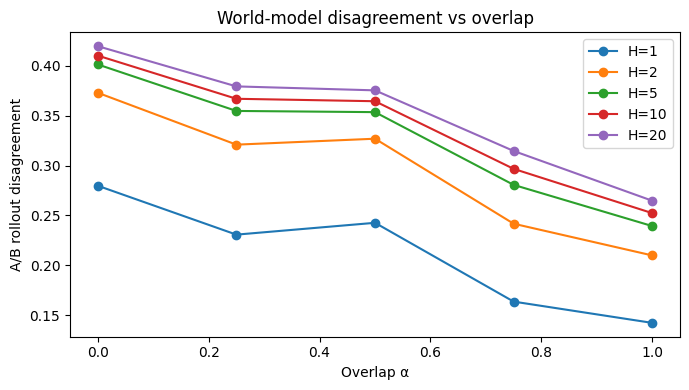

In [ ]:
# Cell 13: Plot 1 — main figure: disagreement vs overlap

plt.figure(figsize=(7, 4))

for H in HORIZONS:
    xs = []
    ys = []
    for alpha in sorted(set(float(r["requested_alpha"]) for r in rollout_results["runs"])):
        vals = []
        for r in rollout_results["runs"]:
            if float(r["requested_alpha"]) == alpha:
                vals.append(float(r["metrics_by_horizon"][str(H)]["AB_disagreement"]))
        xs.append(alpha)
        ys.append(np.mean(vals))
    plt.plot(xs, ys, marker="o", label=f"H={H}")

plt.xlabel("Overlap α")
plt.ylabel("A/B rollout disagreement")
plt.title("World-model disagreement vs overlap")
plt.legend()
plt.tight_layout()
plt.show()

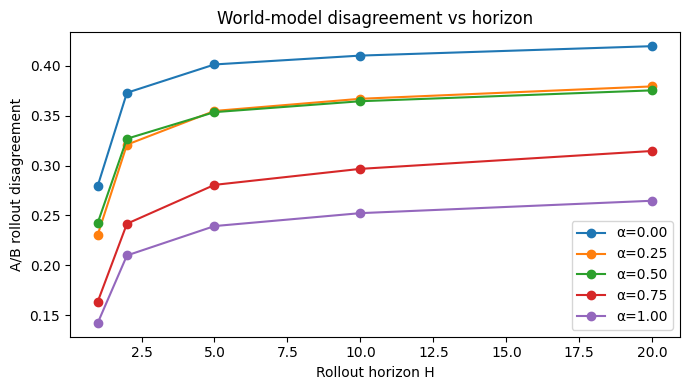

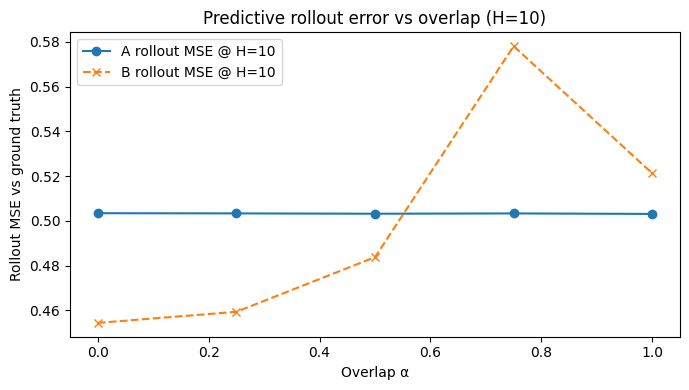

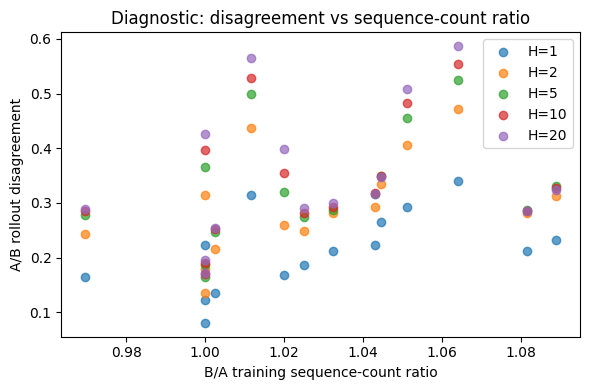

In [ ]:
# Cell 14: Plot 2 — disagreement vs horizon, grouped by alpha

plt.figure(figsize=(7, 4))

alphas_sorted = sorted(set(float(r["requested_alpha"]) for r in rollout_results["runs"]))
for alpha in alphas_sorted:
    ys = []
    for H in HORIZONS:
        vals = []
        for r in rollout_results["runs"]:
            if float(r["requested_alpha"]) == alpha:
                vals.append(float(r["metrics_by_horizon"][str(H)]["AB_disagreement"]))
        ys.append(np.mean(vals))
    plt.plot(HORIZONS, ys, marker="o", label=f"α={alpha:.2f}")

plt.xlabel("Rollout horizon H")
plt.ylabel("A/B rollout disagreement")
plt.title("World-model disagreement vs horizon")
plt.legend()
plt.tight_layout()
plt.show()



# Cell 15: Plot 3 — A/B rollout MSE vs overlap

plt.figure(figsize=(7, 4))

H_plot = 10  # choose a representative horizon
xs = sorted(set(float(r["requested_alpha"]) for r in rollout_results["runs"]))

A_means = []
B_means = []
for alpha in xs:
    valsA, valsB = [], []
    for r in rollout_results["runs"]:
        if float(r["requested_alpha"]) == alpha:
            valsA.append(float(r["metrics_by_horizon"][str(H_plot)]["A_rollout_mse"]))
            valsB.append(float(r["metrics_by_horizon"][str(H_plot)]["B_rollout_mse"]))
    A_means.append(np.mean(valsA))
    B_means.append(np.mean(valsB))

plt.plot(xs, A_means, marker="o", label=f"A rollout MSE @ H={H_plot}")
plt.plot(xs, B_means, marker="x", linestyle="--", label=f"B rollout MSE @ H={H_plot}")
plt.xlabel("Overlap α")
plt.ylabel("Rollout MSE vs ground truth")
plt.title(f"Predictive rollout error vs overlap (H={H_plot})")
plt.legend()
plt.tight_layout()
plt.show()



# Cell 16: Plot 4 — disagreement vs sequence-count ratio (diagnostic)

plt.figure(figsize=(6, 4))

for H in HORIZONS:
    xs = []
    ys = []
    for r in rollout_results["runs"]:
        ratio = r.get("sequence_count_ratio", None)
        if ratio is not None:
            xs.append(float(ratio))
            ys.append(float(r["metrics_by_horizon"][str(H)]["AB_disagreement"]))
    plt.scatter(xs, ys, label=f"H={H}", alpha=0.7)

plt.xlabel("B/A training sequence-count ratio")
plt.ylabel("A/B rollout disagreement")
plt.title("Diagnostic: disagreement vs sequence-count ratio")
plt.legend()
plt.tight_layout()
plt.show()

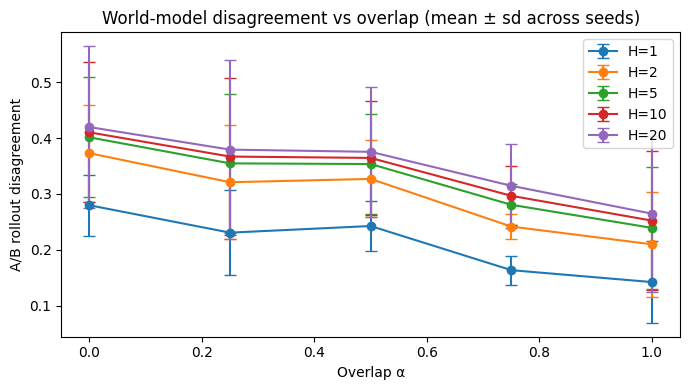

In [ ]:
# Cell 17: Plot with error bars across seeds

import numpy as np
import matplotlib.pyplot as plt

with open(ROLL_RESULTS_PATH, "r") as f:
    rollout_results = json.load(f)

alphas_sorted = sorted(set(float(r["requested_alpha"]) for r in rollout_results["runs"]))

plt.figure(figsize=(7, 4))

for H in HORIZONS:
    xs, means, stds = [], [], []
    for alpha in alphas_sorted:
        vals = [
            float(r["metrics_by_horizon"][str(H)]["AB_disagreement"])
            for r in rollout_results["runs"]
            if float(r["requested_alpha"]) == alpha
        ]
        xs.append(alpha)
        means.append(np.mean(vals))
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    plt.errorbar(xs, means, yerr=stds, marker="o", capsize=4, label=f"H={H}")

plt.xlabel("Overlap α")
plt.ylabel("A/B rollout disagreement")
plt.title("World-model disagreement vs overlap (mean ± sd across seeds)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 18: Sequence-count ratio summary by alpha

print("Sequence-count ratio by alpha:")
for alpha in alphas_sorted:
    vals = [
        float(r["sequence_count_ratio"])
        for r in rollout_results["runs"]
        if float(r["requested_alpha"]) == alpha and r.get("sequence_count_ratio") is not None
    ]
    print(
        f"alpha={alpha:.2f} | "
        f"mean={np.mean(vals):.4f} | min={np.min(vals):.4f} | max={np.max(vals):.4f}"
    )

Sequence-count ratio by alpha:
alpha=0.00 | mean=1.0658 | min=1.0445 | max=1.0889
alpha=0.25 | mean=1.0209 | min=0.9696 | max=1.0816
alpha=0.50 | mean=1.0422 | min=1.0324 | max=1.0511
alpha=0.75 | mean=1.0158 | min=1.0025 | max=1.0249
alpha=1.00 | mean=1.0000 | min=1.0000 | max=1.0000


In [ ]:
# Cell 19: Correlation between sequence-count ratio and disagreement

for H in HORIZONS:
    xs, ys = [], []
    for r in rollout_results["runs"]:
        ratio = r.get("sequence_count_ratio", None)
        if ratio is not None:
            xs.append(float(ratio))
            ys.append(float(r["metrics_by_horizon"][str(H)]["AB_disagreement"]))
    corr = np.corrcoef(xs, ys)[0, 1]
    print(f"H={H:>2d} | corr(sequence_count_ratio, disagreement) = {corr:.4f}")

H= 1 | corr(sequence_count_ratio, disagreement) = 0.5344
H= 2 | corr(sequence_count_ratio, disagreement) = 0.4675
H= 5 | corr(sequence_count_ratio, disagreement) = 0.3707
H=10 | corr(sequence_count_ratio, disagreement) = 0.3165
H=20 | corr(sequence_count_ratio, disagreement) = 0.2734


In [ ]:
# Cell 20: Milestone-conditioned rollout disagreement

@torch.no_grad()
def evaluate_pair_rollouts_milestone_conditioned(
    A_ckpt_path,
    B_ckpt_path,
    test_seqs,
    horizons,
    step_offset=0,
    cap=None,
    batch_size=32,
    seed=0
):
    wmA, ckptA, cfgA = load_world_model_from_ckpt(A_ckpt_path)
    wmB, ckptB, cfgB = load_world_model_from_ckpt(B_ckpt_path)

    dl, n_eval_seqs = make_loader(test_seqs, batch_size=batch_size, shuffle=False, cap=cap, seed=seed)

    sums = {
        H: {
            "milestone_dis_sum": 0.0,
            "milestone_n": 0,
            "background_dis_sum": 0.0,
            "background_n": 0,
        }
        for H in horizons
    }

    for s, a, r, cont in tqdm(dl, desc="milestone-rollout-eval", leave=False):
        s = s.to(DEVICE, non_blocking=True)
        a = a.to(DEVICE, non_blocking=True)
        r = r.to(DEVICE, non_blocking=True)

        predA = rollout_predictions_from_offset(wmA, s, a, step_offset=step_offset, horizons=horizons)
        predB = rollout_predictions_from_offset(wmB, s, a, step_offset=step_offset, horizons=horizons)

        # milestone condition is based on anchor reward r_t
        milestone_mask = (r[:, step_offset] > 0)   # (B,)
        background_mask = ~milestone_mask

        for H in horizons:
            sA = predA[H]
            sB = predB[H]
            dis = ((sA - sB) ** 2).mean(dim=1)  # (B,)

            if milestone_mask.any():
                sums[H]["milestone_dis_sum"] += dis[milestone_mask].sum().item()
                sums[H]["milestone_n"] += int(milestone_mask.sum().item())

            if background_mask.any():
                sums[H]["background_dis_sum"] += dis[background_mask].sum().item()
                sums[H]["background_n"] += int(background_mask.sum().item())

    out = {}
    for H in horizons:
        m_n = max(sums[H]["milestone_n"], 1)
        b_n = max(sums[H]["background_n"], 1)
        out[H] = {
            "milestone_AB_disagreement": sums[H]["milestone_dis_sum"] / m_n,
            "milestone_n": int(sums[H]["milestone_n"]),
            "background_AB_disagreement": sums[H]["background_dis_sum"] / b_n,
            "background_n": int(sums[H]["background_n"]),
        }

    del wmA, wmB
    torch.cuda.empty_cache()
    return out, n_eval_seqs

In [ ]:
# Cell 21: Sweep milestone-conditioned disagreement

with open(ROLL_RESULTS_PATH, "r") as f:
    rollout_results = json.load(f)

for run in rollout_results["runs"]:
    alpha = float(run["requested_alpha"])
    seed  = int(run["seed"])
    A_ckpt = run["A_checkpoint_path"]
    B_ckpt = run["B_checkpoint_path"]

    print(f"\nMilestone-conditioned eval alpha={alpha:.2f} seed={seed}")

    metrics_H, _ = evaluate_pair_rollouts_milestone_conditioned(
        A_ckpt_path=A_ckpt,
        B_ckpt_path=B_ckpt,
        test_seqs=test_seqs,
        horizons=HORIZONS,
        step_offset=STEP_OFFSET,
        cap=TEST_CAP,
        batch_size=BATCH_SIZE,
        seed=SEED_EVAL + 5000 + seed,
    )

    run["milestone_metrics_by_horizon"] = {str(H): metrics_H[H] for H in HORIZONS}

with open(ROLL_RESULTS_PATH, "w") as f:
    json.dump(rollout_results, f, indent=2)

print("Updated rollout_results.json with milestone-conditioned metrics.")


Milestone-conditioned eval alpha=0.00 seed=1337


milestone-rollout-eval:   0%|          | 0/4677 [00:00<?, ?it/s]


Milestone-conditioned eval alpha=0.00 seed=1338


milestone-rollout-eval:   0%|          | 0/4677 [00:00<?, ?it/s]


Milestone-conditioned eval alpha=0.00 seed=1339


...


Milestone-conditioned eval alpha=1.00 seed=1338


milestone-rollout-eval:   0%|          | 0/4677 [00:00<?, ?it/s]


Milestone-conditioned eval alpha=1.00 seed=1339


milestone-rollout-eval:   0%|          | 0/4677 [00:00<?, ?it/s]

Updated rollout_results.json with milestone-conditioned metrics.


In [ ]:
# Cell 22: Milestone-conditioned summary

with open(ROLL_RESULTS_PATH, "r") as f:
    rollout_results = json.load(f)

print("Alpha-averaged milestone-conditioned disagreement:")
for alpha in alphas_sorted:
    print(f"\nalpha={alpha:.2f}")
    for H in HORIZONS:
        m_vals = []
        b_vals = []
        m_ns = []
        for r in rollout_results["runs"]:
            if float(r["requested_alpha"]) == alpha:
                mm = r["milestone_metrics_by_horizon"][str(H)]
                m_vals.append(float(mm["milestone_AB_disagreement"]))
                b_vals.append(float(mm["background_AB_disagreement"]))
                m_ns.append(int(mm["milestone_n"]))
        print(
            f"  H={H:>2d} | "
            f"milestone_dis={np.mean(m_vals):.6f} | "
            f"background_dis={np.mean(b_vals):.6f} | "
            f"avg_milestone_n={np.mean(m_ns):.1f}"
        )

Alpha-averaged milestone-conditioned disagreement:

alpha=0.00
  H= 1 | milestone_dis=0.058408 | background_dis=0.279771 | avg_milestone_n=113.0
  H= 2 | milestone_dis=0.081615 | background_dis=0.372931 | avg_milestone_n=113.0
  H= 5 | milestone_dis=0.091886 | background_dis=0.401145 | avg_milestone_n=113.0
  H=10 | milestone_dis=0.093763 | background_dis=0.409932 | avg_milestone_n=113.0
  H=20 | milestone_dis=0.098366 | background_dis=0.419318 | avg_milestone_n=113.0

alpha=0.25
  H= 1 | milestone_dis=0.065082 | background_dis=0.230898 | avg_milestone_n=113.0
  H= 2 | milestone_dis=0.084689 | background_dis=0.321174 | avg_milestone_n=113.0
  H= 5 | milestone_dis=0.093146 | background_dis=0.354933 | avg_milestone_n=113.0
  H=10 | milestone_dis=0.096995 | background_dis=0.367244 | avg_milestone_n=113.0
  H=20 | milestone_dis=0.098288 | background_dis=0.379841 | avg_milestone_n=113.0

alpha=0.50
  H= 1 | milestone_dis=0.055163 | background_dis=0.242865 | avg_milestone_n=113.0
  H= 2 | mi

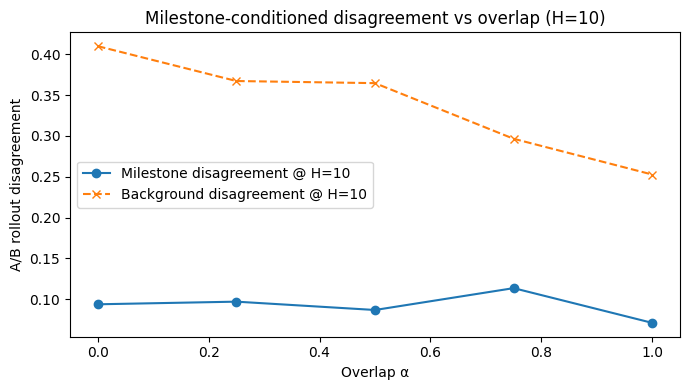

In [ ]:
# Cell 23: Plot milestone vs background disagreement

plt.figure(figsize=(7, 4))

H_plot = 10

milestone_means = []
background_means = []

for alpha in alphas_sorted:
    m_vals = []
    b_vals = []
    for r in rollout_results["runs"]:
        if float(r["requested_alpha"]) == alpha:
            mm = r["milestone_metrics_by_horizon"][str(H_plot)]
            m_vals.append(float(mm["milestone_AB_disagreement"]))
            b_vals.append(float(mm["background_AB_disagreement"]))
    milestone_means.append(np.mean(m_vals))
    background_means.append(np.mean(b_vals))

plt.plot(alphas_sorted, milestone_means, marker="o", label=f"Milestone disagreement @ H={H_plot}")
plt.plot(alphas_sorted, background_means, marker="x", linestyle="--", label=f"Background disagreement @ H={H_plot}")
plt.xlabel("Overlap α")
plt.ylabel("A/B rollout disagreement")
plt.title(f"Milestone-conditioned disagreement vs overlap (H={H_plot})")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Sanity Check A: structural integrity of rollout_results.json

import os, json, math

with open(ROLL_RESULTS_PATH, "r") as f:
    rollout_results = json.load(f)

assert "runs" in rollout_results, "Missing 'runs' in rollout_results.json"
assert len(rollout_results["runs"]) == 15, f"Expected 15 overlap runs, got {len(rollout_results['runs'])}"

required_top_fields = [
    "requested_alpha",
    "seed",
    "A_checkpoint_path",
    "B_checkpoint_path",
    "metrics_by_horizon",
    "milestone_metrics_by_horizon",
]

required_metric_fields = [
    "A_rollout_mse",
    "B_rollout_mse",
    "AB_disagreement",
    "n",
]

required_milestone_fields = [
    "milestone_AB_disagreement",
    "milestone_n",
    "background_AB_disagreement",
    "background_n",
]

for i, run in enumerate(rollout_results["runs"]):
    for k in required_top_fields:
        assert k in run, f"Run {i} missing field: {k}"

    assert os.path.exists(run["A_checkpoint_path"]), f"A checkpoint missing: {run['A_checkpoint_path']}"
    assert os.path.exists(run["B_checkpoint_path"]), f"B checkpoint missing: {run['B_checkpoint_path']}"

    metrics_by_h = run["metrics_by_horizon"]
    milestone_by_h = run["milestone_metrics_by_horizon"]

    for H in HORIZONS:
        Hs = str(H)
        assert Hs in metrics_by_h, f"Run {i} missing horizon {Hs} in metrics_by_horizon"
        assert Hs in milestone_by_h, f"Run {i} missing horizon {Hs} in milestone_metrics_by_horizon"

        for k in required_metric_fields:
            assert k in metrics_by_h[Hs], f"Run {i}, H={Hs} missing metric field: {k}"

        for k in required_milestone_fields:
            assert k in milestone_by_h[Hs], f"Run {i}, H={Hs} missing milestone field: {k}"

print("Structural sanity check passed.")

Structural sanity check passed.


In [ ]:
# Sanity Check B: numeric validity

def is_bad_number(x):
    return (x is None) or (isinstance(x, float) and (math.isnan(x) or math.isinf(x)))

bad = []

for i, run in enumerate(rollout_results["runs"]):
    alpha = run["requested_alpha"]
    seed = run["seed"]

    for H in HORIZONS:
        # Main rollout metrics
        m = run["metrics_by_horizon"][str(H)]

        A_mse = float(m["A_rollout_mse"])
        B_mse = float(m["B_rollout_mse"])
        AB_dis = float(m["AB_disagreement"])
        n = int(m["n"])

        if is_bad_number(A_mse) or A_mse < 0:
            bad.append((alpha, seed, H, "A_rollout_mse", A_mse))
        if is_bad_number(B_mse) or B_mse < 0:
            bad.append((alpha, seed, H, "B_rollout_mse", B_mse))
        if is_bad_number(AB_dis) or AB_dis < 0:
            bad.append((alpha, seed, H, "AB_disagreement", AB_dis))
        if n <= 0:
            bad.append((alpha, seed, H, "n", n))

        # Milestone-conditioned metrics
        mm = run["milestone_metrics_by_horizon"][str(H)]

        m_dis = float(mm["milestone_AB_disagreement"])
        b_dis = float(mm["background_AB_disagreement"])
        m_n = int(mm["milestone_n"])
        b_n = int(mm["background_n"])

        if is_bad_number(m_dis) or m_dis < 0:
            bad.append((alpha, seed, H, "milestone_AB_disagreement", m_dis))
        if is_bad_number(b_dis) or b_dis < 0:
            bad.append((alpha, seed, H, "background_AB_disagreement", b_dis))
        if m_n < 0:
            bad.append((alpha, seed, H, "milestone_n", m_n))
        if b_n < 0:
            bad.append((alpha, seed, H, "background_n", b_n))

if len(bad) == 0:
    print("Numeric sanity check passed.")
else:
    print("Found bad values:")
    for x in bad:
        print(x)
    raise ValueError("Numeric sanity check failed.")

Numeric sanity check passed.


In [ ]:
# Sanity Check C: weak behavioral checks

from collections import defaultdict
import numpy as np

# 1) n should match across horizons inside each run
for run in rollout_results["runs"]:
    ns = [int(run["metrics_by_horizon"][str(H)]["n"]) for H in HORIZONS]
    assert len(set(ns)) == 1, f"n mismatch across horizons for alpha={run['requested_alpha']} seed={run['seed']}: {ns}"

print("Per-run horizon sample counts are consistent.")

# 2) summarize disagreement by alpha and horizon
alpha_to_dis = defaultdict(lambda: defaultdict(list))
for run in rollout_results["runs"]:
    alpha = float(run["requested_alpha"])
    for H in HORIZONS:
        alpha_to_dis[alpha][H].append(float(run["metrics_by_horizon"][str(H)]["AB_disagreement"]))

print("\nMean disagreement by alpha/horizon:")
for alpha in sorted(alpha_to_dis.keys()):
    row = []
    for H in HORIZONS:
        row.append(f"H={H}: {np.mean(alpha_to_dis[alpha][H]):.6f}")
    print(f"alpha={alpha:.2f} | " + " | ".join(row))

# 3) simple monotonicity score by run: how often disagreement increases with horizon
print("\nPer-run disagreement growth with horizon:")
growth_scores = []
for run in rollout_results["runs"]:
    vals = [float(run["metrics_by_horizon"][str(H)]["AB_disagreement"]) for H in HORIZONS]
    inc = sum(vals[j] >= vals[j-1] for j in range(1, len(vals)))
    growth_scores.append(inc)
    print(
        f"alpha={run['requested_alpha']:.2f} seed={run['seed']} | "
        f"vals={[round(v, 6) for v in vals]} | nondecreasing_steps={inc}/{len(HORIZONS)-1}"
    )

print(f"\nAverage nondecreasing horizon steps: {np.mean(growth_scores):.2f} / {len(HORIZONS)-1}")

Per-run horizon sample counts are consistent.

Mean disagreement by alpha/horizon:
alpha=0.00 | H=1: 0.279789 | H=2: 0.373038 | H=5: 0.401424 | H=10: 0.410305 | H=20: 0.419749
alpha=0.25 | H=1: 0.230753 | H=2: 0.320995 | H=5: 0.354791 | H=10: 0.366988 | H=20: 0.379405
alpha=0.50 | H=1: 0.242618 | H=2: 0.326945 | H=5: 0.353597 | H=10: 0.364536 | H=20: 0.375438
alpha=0.75 | H=1: 0.163590 | H=2: 0.241705 | H=5: 0.280650 | H=10: 0.296717 | H=20: 0.314652
alpha=1.00 | H=1: 0.142255 | H=2: 0.209885 | H=5: 0.239343 | H=10: 0.252308 | H=20: 0.264737

Per-run disagreement growth with horizon:
alpha=0.00 seed=1337 | vals=[0.23301, 0.312009, 0.330553, 0.327359, 0.324552] | nondecreasing_steps=2/4
alpha=0.00 seed=1338 | vals=[0.266163, 0.334733, 0.348914, 0.34916, 0.34821] | nondecreasing_steps=3/4
alpha=0.00 seed=1339 | vals=[0.340195, 0.472372, 0.524804, 0.554395, 0.586486] | nondecreasing_steps=4/4
alpha=0.25 seed=1337 | vals=[0.211781, 0.281868, 0.286979, 0.285647, 0.285577] | nondecreasing_st

In [ ]:
# Sanity Check D: alpha-averaged summary table

import numpy as np

print("Alpha-averaged metrics:")
for alpha in sorted(set(float(r["requested_alpha"]) for r in rollout_results["runs"])):
    print(f"\nalpha={alpha:.2f}")
    for H in HORIZONS:
        A_vals = []
        B_vals = []
        D_vals = []
        for r in rollout_results["runs"]:
            if float(r["requested_alpha"]) == alpha:
                m = r["metrics_by_horizon"][str(H)]
                A_vals.append(float(m["A_rollout_mse"]))
                B_vals.append(float(m["B_rollout_mse"]))
                D_vals.append(float(m["AB_disagreement"]))
        print(
            f"  H={H:>2d} | "
            f"A_mse={np.mean(A_vals):.6f} | "
            f"B_mse={np.mean(B_vals):.6f} | "
            f"AB_dis={np.mean(D_vals):.6f}"
        )

Alpha-averaged metrics:

alpha=0.00
  H= 1 | A_mse=0.440739 | B_mse=0.414953 | AB_dis=0.279789
  H= 2 | A_mse=0.463277 | B_mse=0.429040 | AB_dis=0.373038
  H= 5 | A_mse=0.488281 | B_mse=0.442793 | AB_dis=0.401424
  H=10 | A_mse=0.503440 | B_mse=0.454434 | AB_dis=0.410305
  H=20 | A_mse=0.522720 | B_mse=0.470306 | AB_dis=0.419749

alpha=0.25
  H= 1 | A_mse=0.440719 | B_mse=0.440218 | AB_dis=0.230753
  H= 2 | A_mse=0.463222 | B_mse=0.442097 | AB_dis=0.320995
  H= 5 | A_mse=0.488174 | B_mse=0.452378 | AB_dis=0.354791
  H=10 | A_mse=0.503351 | B_mse=0.459385 | AB_dis=0.366988
  H=20 | A_mse=0.522718 | B_mse=0.470214 | AB_dis=0.379405

alpha=0.50
  H= 1 | A_mse=0.440624 | B_mse=0.458497 | AB_dis=0.242618
  H= 2 | A_mse=0.463111 | B_mse=0.467290 | AB_dis=0.326945
  H= 5 | A_mse=0.488036 | B_mse=0.474611 | AB_dis=0.353597
  H=10 | A_mse=0.503204 | B_mse=0.483800 | AB_dis=0.364536
  H=20 | A_mse=0.522518 | B_mse=0.497905 | AB_dis=0.375438

alpha=0.75
  H= 1 | A_mse=0.440734 | B_mse=0.527415 | 

In [ ]:
# Define experiment constants used in Notebook 5
ALPHAS = [0.0, 0.25, 0.50, 0.75, 1.0]
SEEDS = [1337, 1338, 1339]

In [ ]:
# Sanity Check E: exact inventory check


expected_pairs = {(float(a), int(s)) for a in ALPHAS for s in SEEDS}
found_pairs = {(float(r["requested_alpha"]), int(r["seed"])) for r in rollout_results["runs"]}

missing = expected_pairs - found_pairs
extra = found_pairs - expected_pairs

print("Missing pairs:", missing)
print("Extra pairs:", extra)

assert len(missing) == 0, f"Missing run pairs: {missing}"
assert len(extra) == 0, f"Unexpected run pairs: {extra}"

print("Run inventory check passed.")

Missing pairs: set()
Extra pairs: set()
Run inventory check passed.
